# AI Financial Analytics & Investment Insight Platform

This notebook demonstrates:
- Stock data analysis
- Feature engineering
- Machine learning prediction
- Portfolio optimization
- AI-powered financial insights

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import yfinance as yf

from data_loader import load_stock_data
from features import add_features
from model import train_model
from portfolio import optimize_portfolio

In [2]:
import yfinance as yf
import pandas as pd

data = yf.download("AAPL", start="2019-01-01")
data = data[['Close', 'Volume']]
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(1)
data.dropna(inplace=True)

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,Volume
Date,,
2019-01-02,37.503731,148158800
2019-01-03,33.768078,365248800
2019-01-04,35.209618,234428400
2019-01-07,35.131241,219111200
2019-01-08,35.800957,164101200


In [3]:
# ticker = input("Enter stock ticker (AAPL, TSLA, MSFT): ").upper()
ticker = 'AAPL'

print("Selected:", ticker)

Selected: AAPL


In [4]:
# data = load_stock_data(ticker)
# data = yf.download(ticker)["Close"]
# data.head()

In [5]:
data.describe()

Price,Close,Volume
count,1811.000000,1.811000e+03
mean,151.540184,8.736032e+07
std,63.202828,5.097146e+07
min,33.768078,1.791060e+07
25%,113.513809,5.220140e+07
50%,152.061523,7.477040e+07
75%,192.693214,1.055430e+08
max,285.922455,4.265100e+08


In [6]:
data.isnull().sum()

Price
Close     0
Volume    0
dtype: int64

In [7]:
fig = px.line(
    data,
    x=data.index,
    y=data.columns,
    title=f"{ticker} Stock Price",
)

# Improve layout
fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Price (USD)",
    template="plotly_dark"
)

fig.show()

In [8]:
data = add_features(data)

data.head()

Price,Close,Volume,MA50,MA200,MA_ratio,Price_to_MA50,Return,Momentum_5,Momentum_10,Momentum_20,Volatility,Volatility_10,Volume_MA20,Volume_ratio,RSI,BB_position,Target
Date,,,,,,,,,,,,,,,,,
2019-10-16,56.326675,73903200,51.942472,46.344916,1.120780,1.084405,-0.004037,0.032331,0.070378,0.052072,0.013968,0.013204,112827940.0,0.655008,69.631297,0.731853,1
2019-10-17,56.545372,67585200,52.120286,46.440124,1.122312,1.084901,0.003883,0.022556,0.065483,0.064808,0.013737,0.013223,111795080.0,0.604545,72.412818,0.711896,1
2019-10-18,56.816956,97433600,52.282510,46.555368,1.123018,1.086730,0.004803,0.000847,0.041408,0.085794,0.013080,0.010833,105584140.0,0.922805,69.021412,0.713206,1
2019-10-21,57.802307,87247200,52.472468,46.668332,1.124370,1.101574,0.017343,0.019672,0.059235,0.099625,0.013406,0.011482,106113400.0,0.822207,72.001104,0.883174,0
2019-10-22,57.670132,82293600,52.662235,46.781026,1.125718,1.095095,-0.002287,0.019718,0.069340,0.102352,0.013324,0.010196,103989920.0,0.791361,83.762056,0.759403,1


In [12]:
model,accuracy, cv_score = train_model(data)

print("Model Accuracy:", accuracy)
print("CV Score:", cv_score)

c:\Users\agamb\Desktop\Fin AI\.venv\lib\site-packages\xgboost\training.py:200: UserWarning: [02:44:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\agamb\Desktop\Fin AI\.venv\lib\site-packages\xgboost\training.py:200: UserWarning: [02:44:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\agamb\Desktop\Fin AI\.venv\lib\site-packages\xgboost\training.py:200: UserWarning: [02:44:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\agamb\Desktop\Fin AI\.venv\lib\site-packages\xgboost\training.py:200: UserWarning: [02:44:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_labe

Model Accuracy: 0.5572755417956656
CV Score: 0.5186915887850467


[*********************100%***********************]  5 of 5 completed
C:\Users\agamb\AppData\Local\Temp\ipykernel_14996\2968995650.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(risk[i], mean_returns[i], stocks[i])


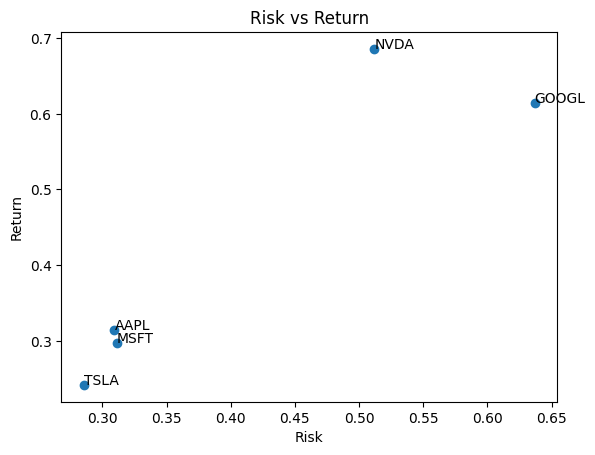

In [10]:
import yfinance as yf
stocks = ["AAPL","MSFT","TSLA","NVDA","GOOGL"]

price_data = yf.download(stocks, start="2019-01-01")["Close"]

returns = price_data.pct_change().dropna()

mean_returns = returns.mean() * 252
risk = returns.std() * (252 ** 0.5)

plt.scatter(risk, mean_returns)

for i in range(len(stocks)):
    plt.text(risk[i], mean_returns[i], stocks[i])

plt.xlabel("Risk")
plt.ylabel("Return")
plt.title("Risk vs Return")

plt.show()

In [11]:
portfolio, p_return, p_risk = optimize_portfolio(stocks)

portfolio
print("Portfolio Return:", p_return)
print("Portfolio Risk:", p_risk)

[*********************100%***********************]  5 of 5 completed

Portfolio Return: 0.4075146199376592
Portfolio Risk: 0.31821315103465964
